# EDA данных сегментации повреждений автомобилей

Для обучения сегментации повреждений был выбран датасет [CarDD](https://www.kaggle.com/datasets/issamjebnouni/cardd), а для определения части автомобиля, на которой произошло повреждение - [Car parts](https://www.kaggle.com/datasets/ruiite/car-parts-dataset). Данные были получены в формате COCO, далее предполагается обучать модели YOLO-seg, в силу чего данные были приведены к формату YOLO. Позже для дообучения и тестирования предполагается получить дополнительные данные от куратора и разметить их вручную и с использованием автоматических инструментов разметки.

In [1]:
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import yaml
import json
import os

from collections import Counter

In [ ]:
CARDD_YOLO_YAML = Path("data/cardd_merged_yolo_annotation/cardd.yaml")
CARPARTS_YOLO_YAML = Path("data/carparts_yolo_annotation/carparts.yaml")
CARPARTS_COCO_ANNOTATION_TRAIN = Path("data/carparts/remapped/train.json")
CARPARTS_COCO_ANNOTATION_VAL = Path("data/carparts/remapped/val.json")
CARDD_COCO_ANNOTATION_TRAIN = Path("data/cardd/train.json")
CARDD_COCO_ANNOTATION_VAL = Path("data/cardd/val.json")
CARDD_COCO_ANNOTATION_TEST = Path("data/cardd/test.json")

## Функции, использованные в анализе

In [3]:
def plot_yolo_samples(yaml_path, split="train"):
    with open(yaml_path, "r") as f:
        cfg = yaml.safe_load(f)

    base_path = Path(cfg.get("path", ""))
    img_dir = base_path / cfg[split]
    lbl_dir = Path(str(img_dir).replace("images", "labels"))
    if not lbl_dir.exists():
        lbl_dir = Path(str(img_dir).replace("images", "masks"))

    class_names = cfg.get("names", {})
    img_list = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
    samples = random.sample(img_list, min(9, len(img_list)))
    colors = plt.cm.get_cmap("tab10", len(class_names))

    fig, axes = plt.subplots(3, 3, figsize=(18, 18))
    axes = axes.flatten()

    for i, img_path in enumerate(samples):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        lbl_path = lbl_dir / (img_path.stem + ".txt")
        overlay = img.copy()
        labels_to_draw = []

        if lbl_path.exists():
            with open(lbl_path, "r") as f:
                for line in f:
                    data = list(map(float, line.strip().split()))
                    if len(data) < 3:
                        continue

                    cls_id = int(data[0])
                    pts = np.array(data[1:]).reshape(-1, 2)
                    pts[:, 0] *= w
                    pts[:, 1] *= h
                    pts = pts.astype(np.int32)

                    color = [int(c * 255) for c in colors(cls_id)[:3]]
                    cv2.fillPoly(overlay, [pts], color)
                    cv2.polylines(img, [pts], True, (255, 255, 255), 2)

                    # Store label info to draw after blending
                    labels_to_draw.append(
                        (class_names.get(cls_id, str(cls_id)), pts[0], color)
                    )

        # Apply transparency to masks only
        img = cv2.addWeighted(overlay, 0.4, img, 0.6, 0)

        # Draw opaque labels with background
        for text, pos, color in labels_to_draw:
            font = cv2.FONT_HERSHEY_SIMPLEX
            scale = 1.2  # Large text
            thickness = 3

            # Get text size for background box
            (tw, th), baseline = cv2.getTextSize(text, font, scale, thickness)
            tx, ty = pos[0], pos[1] - 10

            # Draw solid background rectangle
            cv2.rectangle(
                img, (tx, ty - th), (tx + tw, ty + baseline), color, -1
            )
            # Draw white text on top
            cv2.putText(
                img, text, (tx, ty), font, scale, (255, 255, 255), thickness
            )

        axes[i].imshow(img)
        axes[i].set_title(img_path.name)
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

In [4]:
def plot_coco_distribution(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    # Map category IDs to names
    id_to_name = {cat["id"]: cat["name"] for cat in data["categories"]}

    # Count occurrences of each category ID
    cat_ids = [ann["category_id"] for ann in data["annotations"]]
    counts = Counter(cat_ids)

    # Prepare data for plotting
    # Use names if available, otherwise use IDs
    labels = [id_to_name.get(cid, f"ID {cid}") for cid in counts.keys()]
    values = list(counts.values())

    # Sort by frequency for better visualization
    sorted_data = sorted(zip(labels, values), key=lambda x: x[1], reverse=True)
    labels, values = zip(*sorted_data)

    # Plotting
    plt.figure(figsize=(10, 6))
    bars = plt.bar(labels, values, color="skyblue")

    # Add value labels on top of bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.5,
            int(yval),
            ha="center",
            va="bottom",
        )

    plt.title(f"Label Distribution: {Path(json_path).name}", fontsize=18)
    plt.xlabel("Category Name", fontsize=16)
    plt.ylabel("Number of Instances", fontsize=16)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()

##  Анализ датасета повреждений - CarDD

In [5]:
with open(CARDD_COCO_ANNOTATION_TRAIN) as cardd_train:
    cardd_train = json.load(cardd_train)

with open(CARDD_COCO_ANNOTATION_VAL) as cardd_val:
    cardd_val = json.load(cardd_val)

with open(CARDD_COCO_ANNOTATION_TEST) as cardd_test:
    cardd_test = json.load(cardd_test)

Ниже представлена общая характеристика наборов данных из датасета CarDD по числу изображений и масок

In [6]:
print(f"Картинок в: \n- трейне {len(cardd_train['images'])}")
print(f"- валидации {len(cardd_val['images'])}")
print(f"- тесте {len(cardd_test['images'])}")

Картинок в: 
- трейне 2816
- валидации 810
- тесте 374


In [7]:
print(f"Объектов в: \n- трейне {len(cardd_train['annotations'])}")
print(f"- валидации {len(cardd_val['annotations'])}")
print(f"- тесте {len(cardd_test['annotations'])}")

Объектов в: 
- трейне 6211
- валидации 1744
- тесте 785


Давайте посмотрим на распределение лейблов по классам

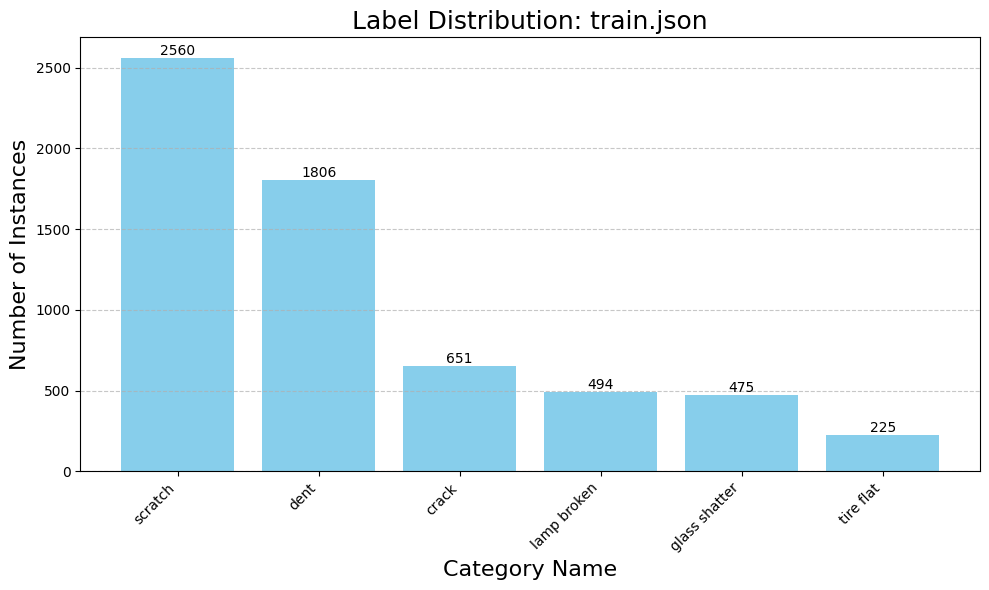

In [8]:
plot_coco_distribution(CARDD_COCO_ANNOTATION_TRAIN)

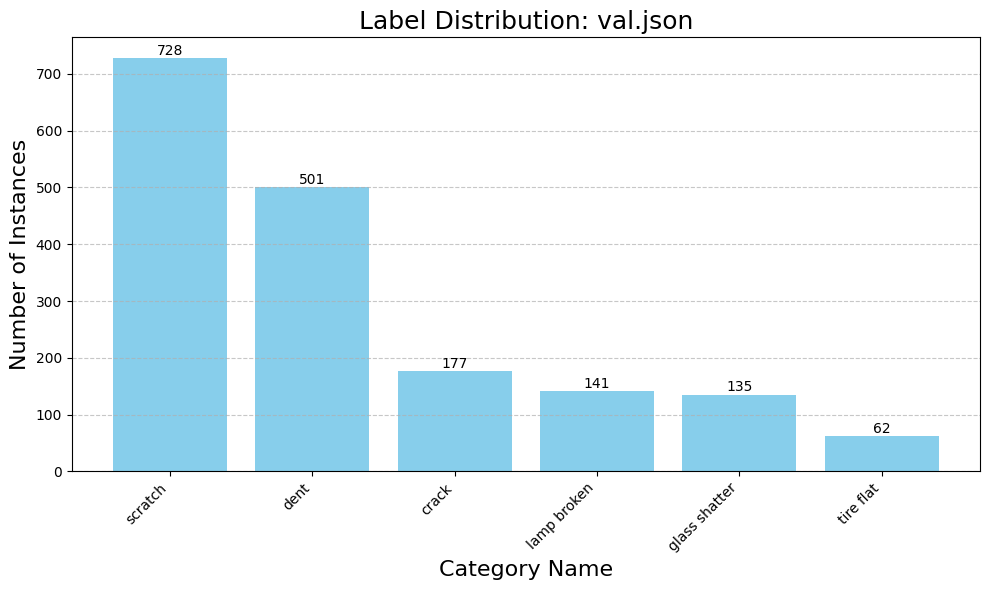

In [9]:
plot_coco_distribution(CARDD_COCO_ANNOTATION_VAL)

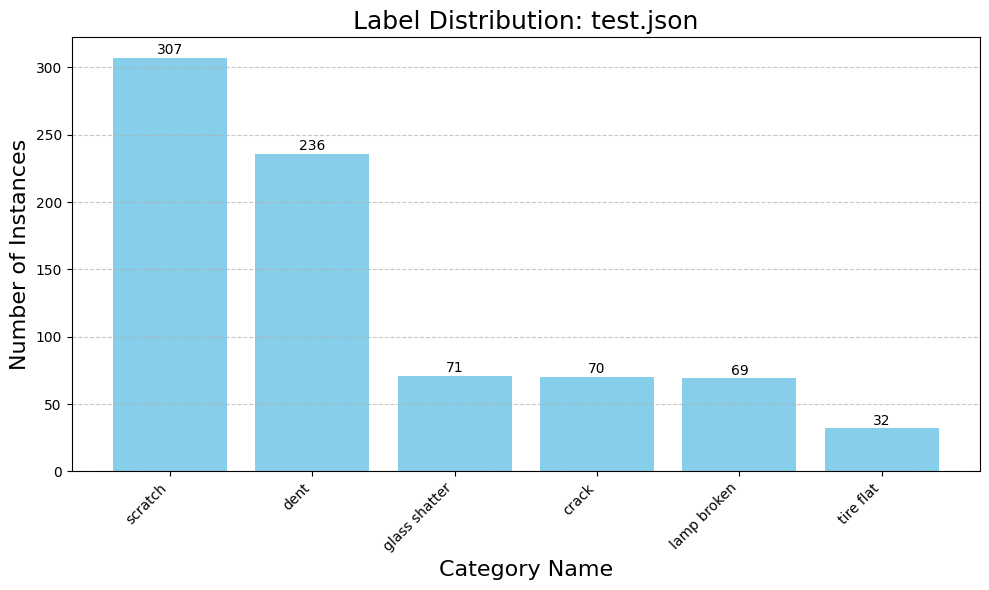

In [10]:
plot_coco_distribution(CARDD_COCO_ANNOTATION_TEST)

Оно примерно совпадает во всех наборах данных: царапина и вмятина наиболее частые, а спущенная шина самая редкая.

Визуальный анализ некоторых случайно выбранных картинок показывает, что повреждения визаульно хорошо различимы на большинстве примеров. Однако мелкие повреждения вроде зарапин могут быть спутаны моделью с бликами или стыками на корпусе. В решении этого вопроса может помочь обильное использование аугментаций, в частности теней и изменения контраста. 

Также нужно учитывать, что большая часть изображений снята крупным планом, что может отличаться от реальных данных в объявлениях. В силу чего после предобучения на этих открытых датестах вероятнее всего потребуется дообучение и тестирование на дополнительных данных, которые планируется получить позднее. 

/tmp/ipykernel_38233/2582585772.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(class_names))


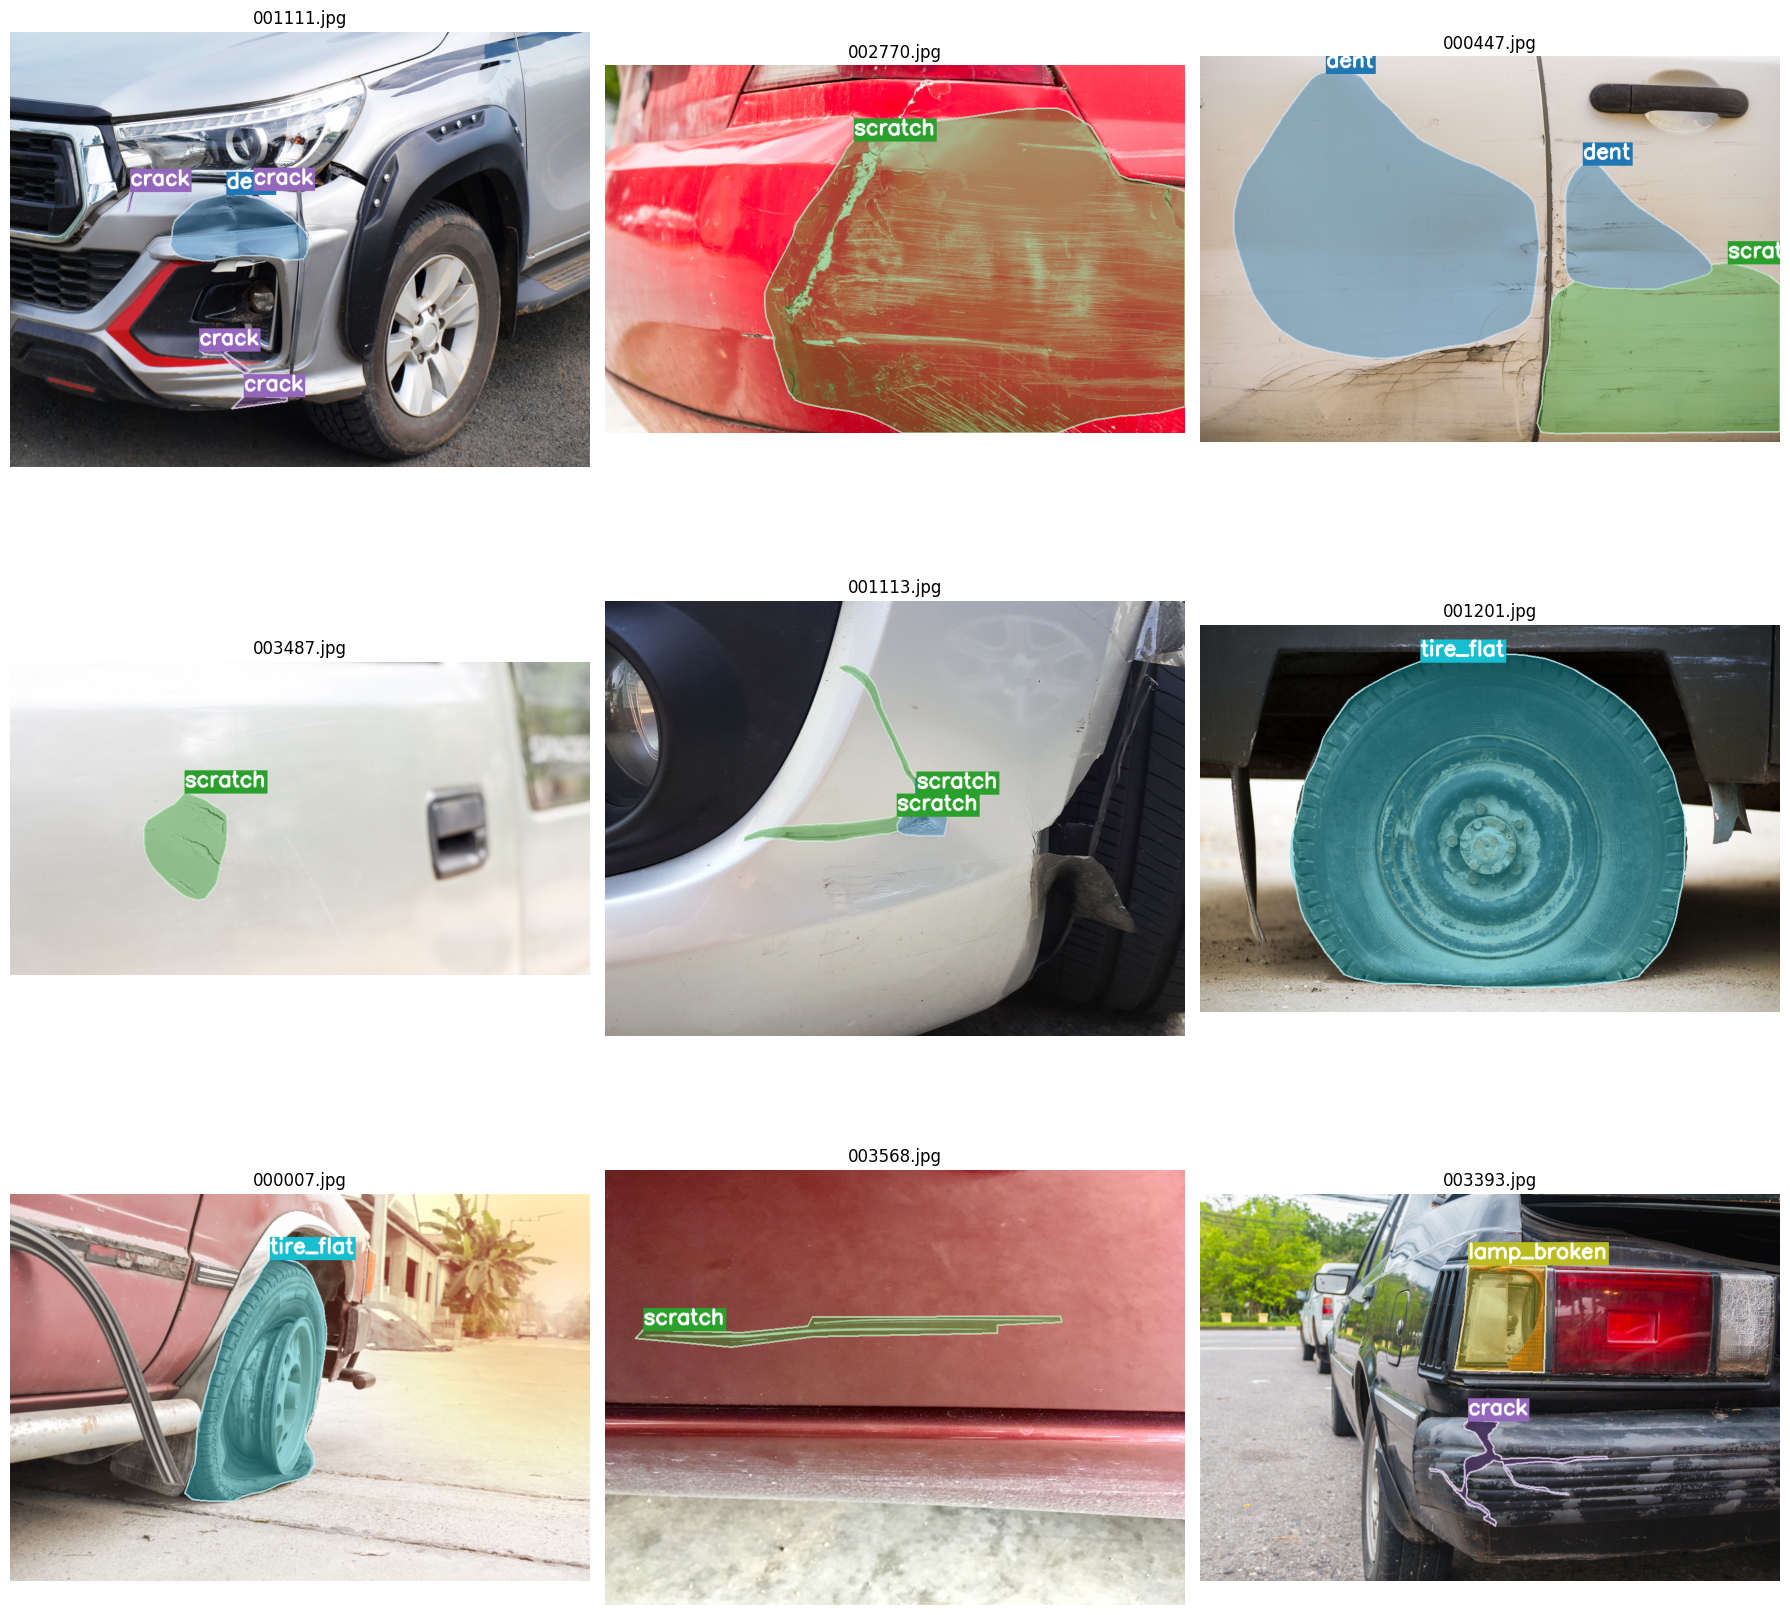

In [11]:
plot_yolo_samples(str(CARDD_YOLO_YAML), split="train")

##  Анализ датасета частей автомобиля - Carparts

In [12]:
with open(CARPARTS_COCO_ANNOTATION_TRAIN) as carparts_train:
    carparts_train = json.load(carparts_train)

with open(CARPARTS_COCO_ANNOTATION_VAL) as carparts_val:
    carparts_val = json.load(carparts_val)

Ниже представлена общая характеристика наборов данных из датасета CarDD по числу изображений и масок

In [13]:
print(f"Картинок в: \n- трейне {len(carparts_train['images'])}")
print(f"- валидации {len(carparts_val['images'])}")

Картинок в: 
- трейне 400
- валидации 100


In [14]:
print(f"Объектов в: \n- трейне {len(carparts_train['annotations'])}")
print(f"- валидации {len(carparts_val['annotations'])}")

Объектов в: 
- трейне 3073
- валидации 811


Давайте посмотрим на распределение лейблов по классам. Классы, представленные здесь были получены путем объединения ряда несущественно отличающихся классов из исходного датасета. В первую очередь объединены были детали, отличающиеся стороной (левая и правая двери и пр.). Это позволит упростить обучение для модели. Полный пайплайн предобработки представлен в `utils/data_process.py`

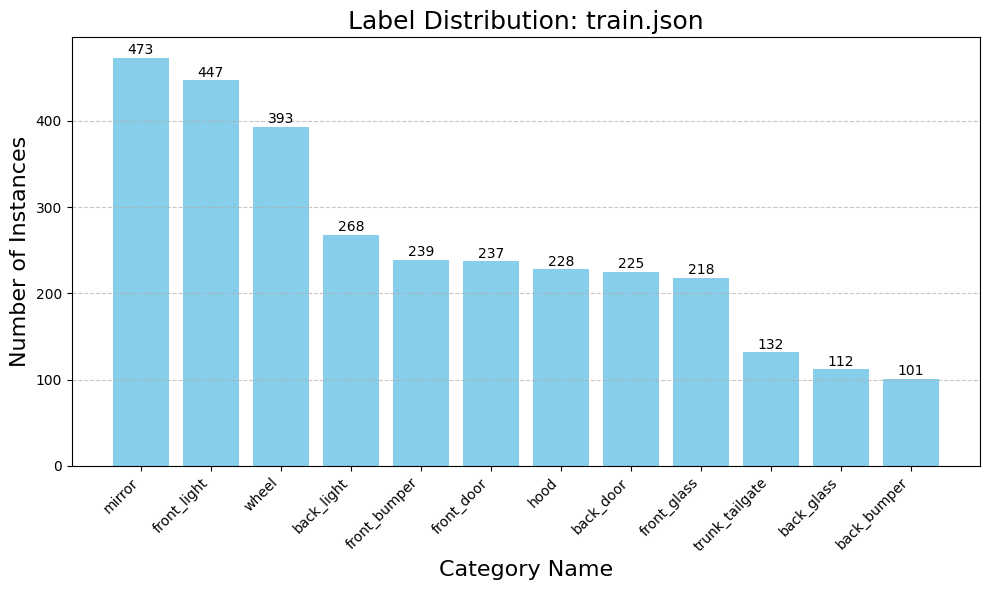

In [15]:
plot_coco_distribution(CARPARTS_COCO_ANNOTATION_TRAIN)

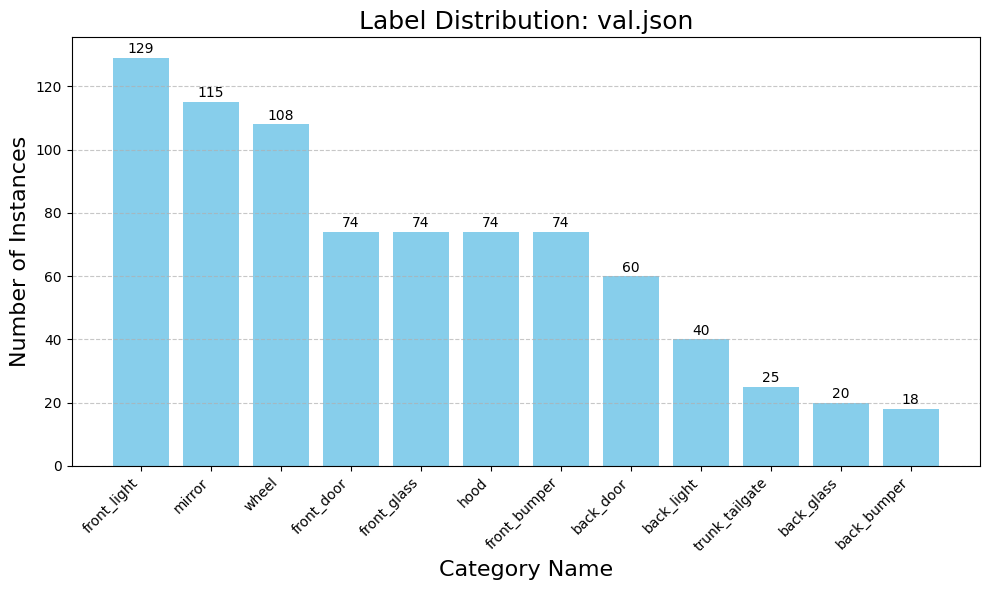

In [16]:
plot_coco_distribution(CARPARTS_COCO_ANNOTATION_VAL)

Оно примерно совпадает во всех наборах данных: заркала и передние фары наиболее частые, а задний бампер - самый редкий.

Визуальный анализ некоторых случайно выбранных картинок показывает, что части автомобилей размечен достаточно качетственно, все участки визуально различимы. Стоит отметить, что некоторые картинки сняты в неестественном контексте. В силу чего после предобучения на этих открытых данных вероятнее всего потребуется дообучение и тестирование на дополнительных данных реальных объявлений, которые планируется получить позднее. 

/tmp/ipykernel_38233/2582585772.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(class_names))


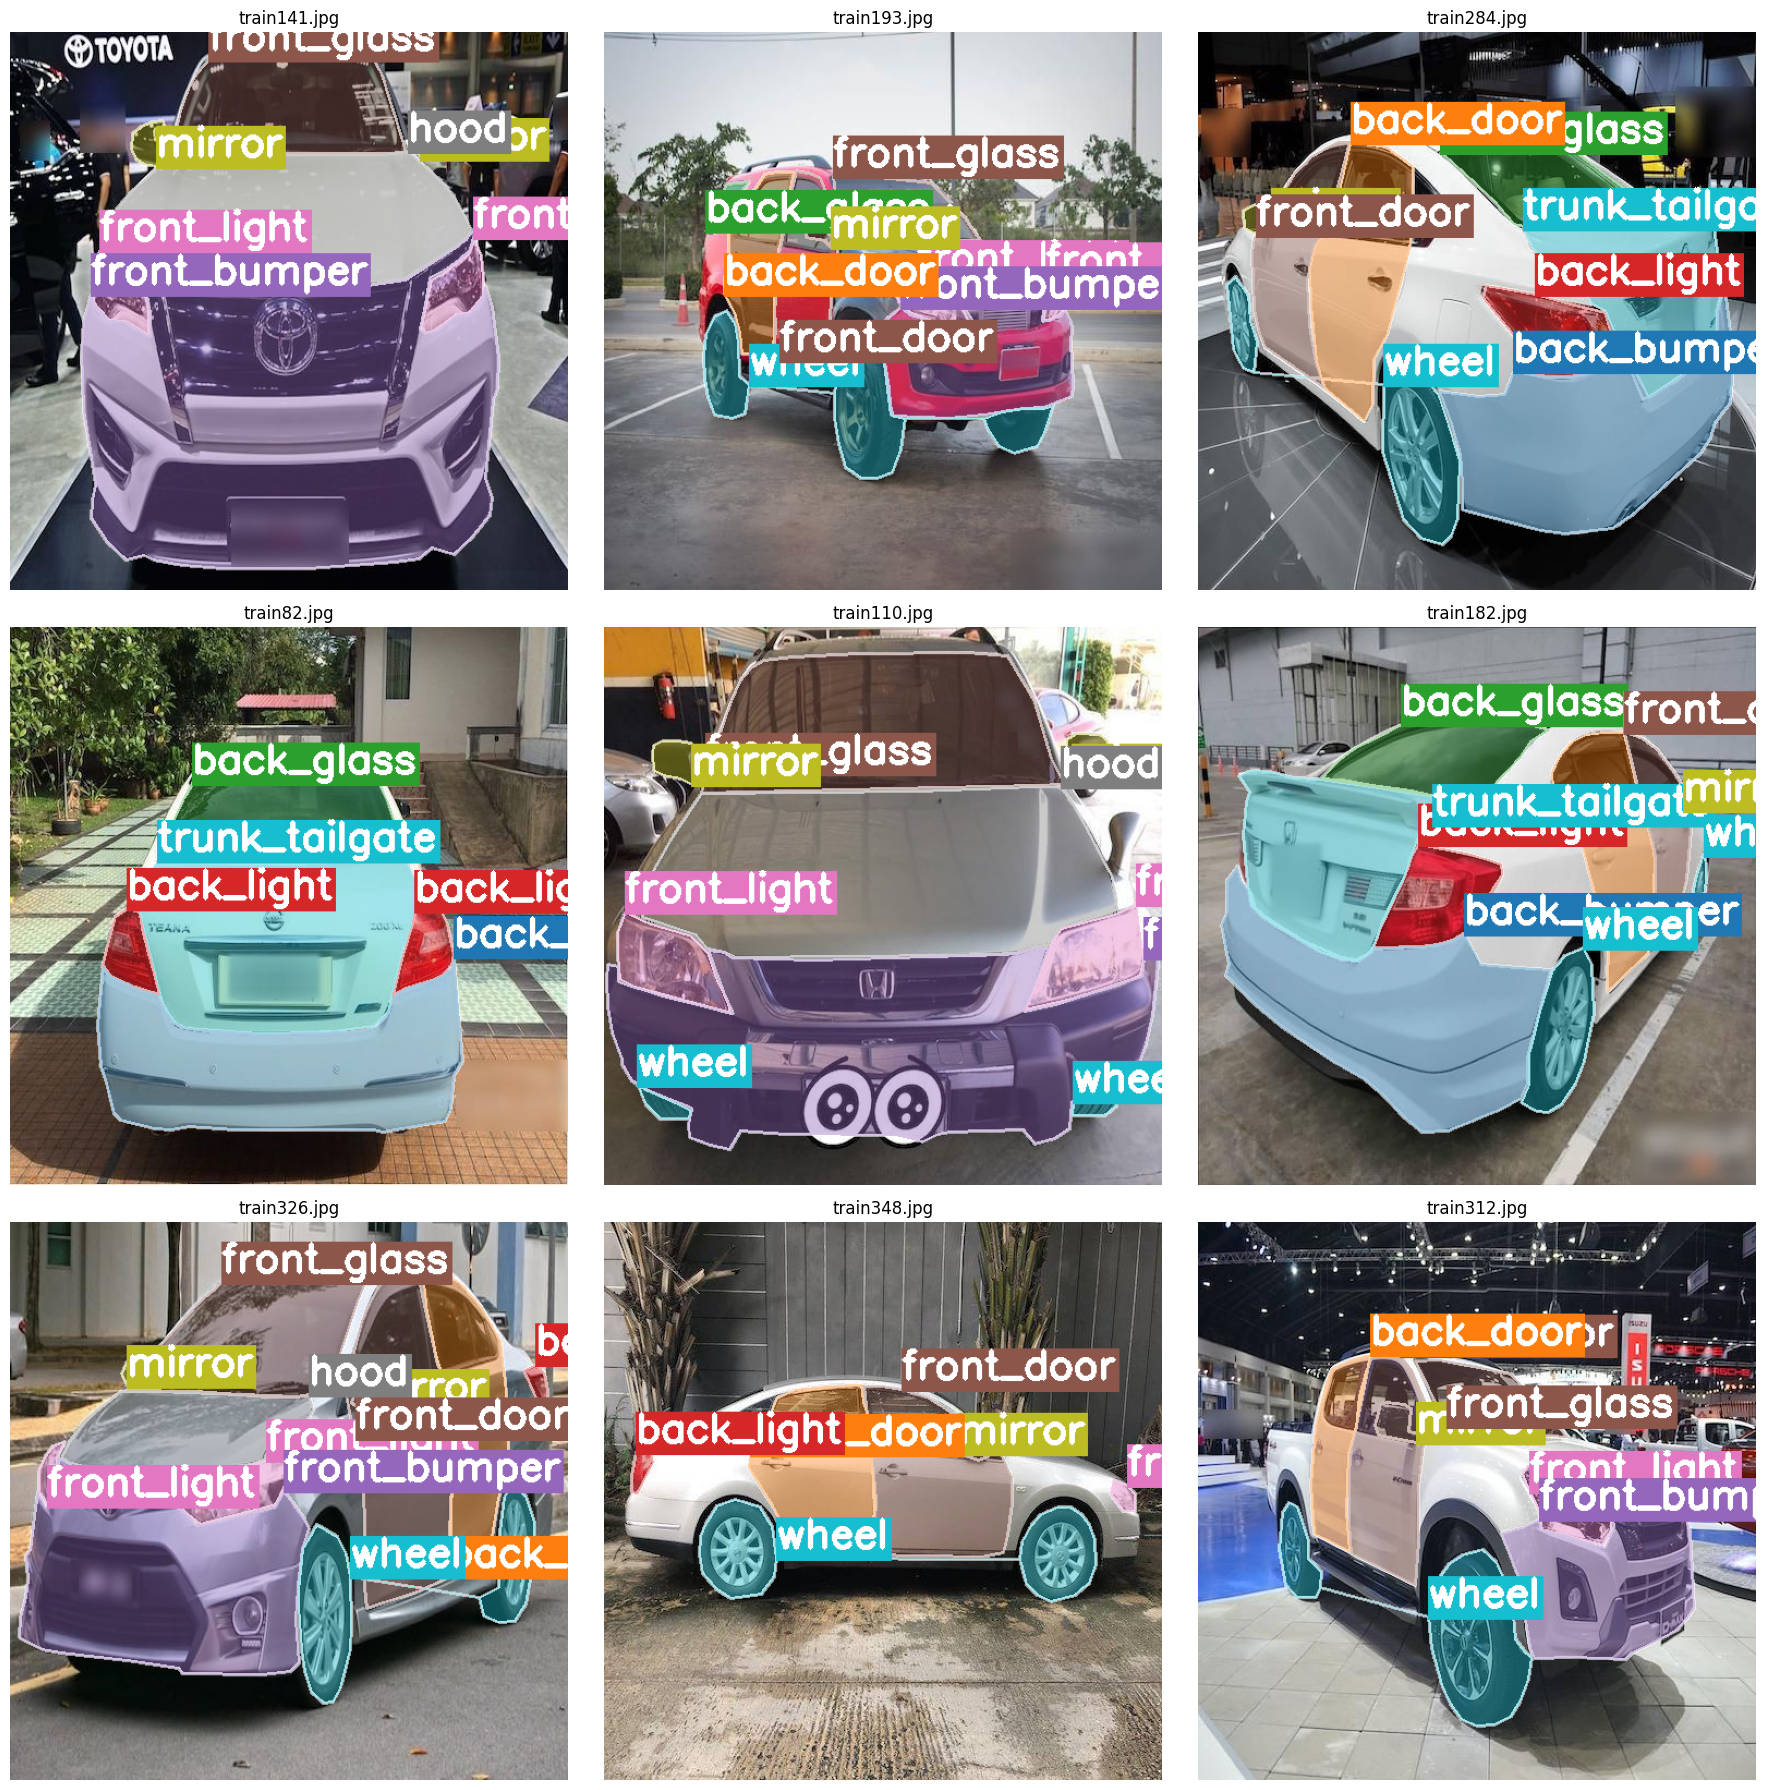

In [17]:
plot_yolo_samples(str(CARPARTS_YOLO_YAML), split="train")

Так как датасет CarDD содержит только участки с повреждениями, в итоговую обучающую выборку для задачи сегментации повреждений были добавлены все картинки из Carparts с пустыми масками в качестве негативных примеров, т е машин без повреждений. Полный пайплайн предобработки в файле `utils/data_process.py`

Финальнуб оценку качества обученных моделей планируется проводить на данных реальных объявлений, которые будут получены позднее.